# Riverine Flooding Analysis

Seasonal Floodscan SFED time series and return period analysis for riverine LGAs along the Benue river. Set `STATE` below to switch between Adamawa and Benue state. Requires the processed Floodscan parquet produced by `10_floodscan_processing.ipynb`.

In [6]:
import pandas as pd
import ocha_stratus as stratus
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from shapely.geometry import box

from src.datasources import hydrosheds, grrr
from src.datasources.glofas import GF_STATIONS
from src.constants import STATE_CONFIG

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

## State configuration

Set `STATE` to `"Benue"` or `"Adamawa"` to switch between the two areas of interest.

In [7]:
STATE = "Adamawa"  # or "Adamawa"
cfg = STATE_CONFIG[STATE]

## Load geolayers

In [8]:
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_rivers = hydrosheds.load_selected_rivers()

gdf_state = gdf_lga[gdf_lga[cfg["adm1_col"]] == cfg["adm1_val"]].copy()
gdf_intersecting = gdf_state[gdf_state["ADM2_PCODE"].isin(cfg["lga_pcodes"])]
gdf_non_intersecting = gdf_state.drop(index=gdf_intersecting.index)

gdf_benue_river = gdf_rivers[
    (gdf_rivers.geometry.centroid.x > cfg["river_x_min"]) & (gdf_rivers.geometry.centroid.y < 10)
].copy()
minx, _, maxx, _ = gdf_state.total_bounds
gdf_river_clipped = gpd.clip(gdf_benue_river, box(minx, -90, maxx, 90))

# GloFAS station
station = GF_STATIONS[cfg["glofas_station"]]

# Google gauge location
_locations_path = (
    "gs://flood-forecasting/hydrologic_predictions/model_id_8583a5c2_v0/"
    "hybas_outlet_locations_UNOFFICIAL.zarr/"
)
_ds_loc = grrr.open_zarr(_locations_path).sel(gauge_id=cfg["google_gauge"]).compute()
google_coords = {
    "lon": float(_ds_loc["longitude"]),
    "lat": float(_ds_loc["latitude"]),
}

/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_80433/2459186056.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (gdf_rivers.geometry.centroid.x > cfg["river_x_min"]) & (gdf_rivers.geometry.centroid.y < 10)


## LGA overview

Selected riverine LGAs highlighted in blue, with the Benue river and GloFAS station.

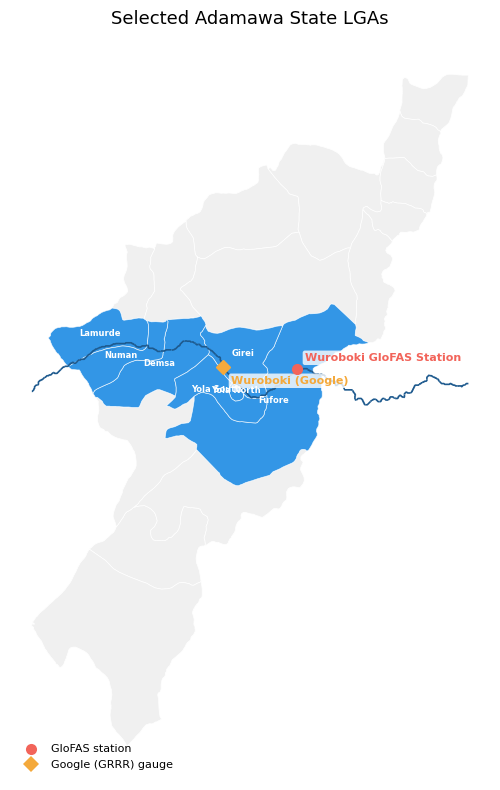

Selected LGAs (7):
['Demsa', 'Fufore', 'Girei', 'Lamurde', 'Numan', 'Yola North', 'Yola South']


In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

gdf_non_intersecting.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)
gdf_intersecting.plot(ax=ax, color="#007CE0", edgecolor="white", linewidth=0.5, alpha=0.8)
gdf_river_clipped.plot(ax=ax, color="#1E5A8E", linewidth=1.2, zorder=3)

# GloFAS station
ax.plot(station["lon"], station["lat"], marker="o", color="#F2645A", markersize=7, zorder=4)
ax.annotate(
    cfg["station_label"],
    xy=(station["lon"], station["lat"]),
    xytext=(6, 6), textcoords="offset points",
    fontsize=8, fontweight="bold", color="#F2645A",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8),
)

# Google gauge
ax.plot(google_coords["lon"], google_coords["lat"], marker="D", color="#F4A93B", markersize=7, zorder=4)
ax.annotate(
    f"{cfg['glofas_station'].title()} (Google)",
    xy=(google_coords["lon"], google_coords["lat"]),
    xytext=(6, -12), textcoords="offset points",
    fontsize=8, fontweight="bold", color="#F4A93B",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8),
)

for _, row in gdf_intersecting.iterrows():
    ax.annotate(
        row["ADM2_EN"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        fontsize=6, ha="center", color="white", fontweight="bold",
    )

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#F2645A",
           markersize=8, markeredgewidth=0, label="GloFAS station"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#F4A93B",
           markersize=8, markeredgewidth=0, label="Google (GRRR) gauge"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=8, loc="lower left")

ax.set_axis_off()
ax.set_title(f"Selected {STATE} State LGAs", fontsize=13, pad=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{STATE.lower()}_lgas_river.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Selected LGAs ({len(gdf_intersecting)}):")
print(sorted(gdf_intersecting["ADM2_EN"].tolist()))

## Floodscan SFED time series

Daily mean SFED across all selected pixels, plotted as one line per year aligned to a Jan–Dec axis. Return period thresholds are derived from wet-season (Jul–Nov) annual maxima. Years exceeding the 3-, 4-, or 5-year RP are coloured and labelled.

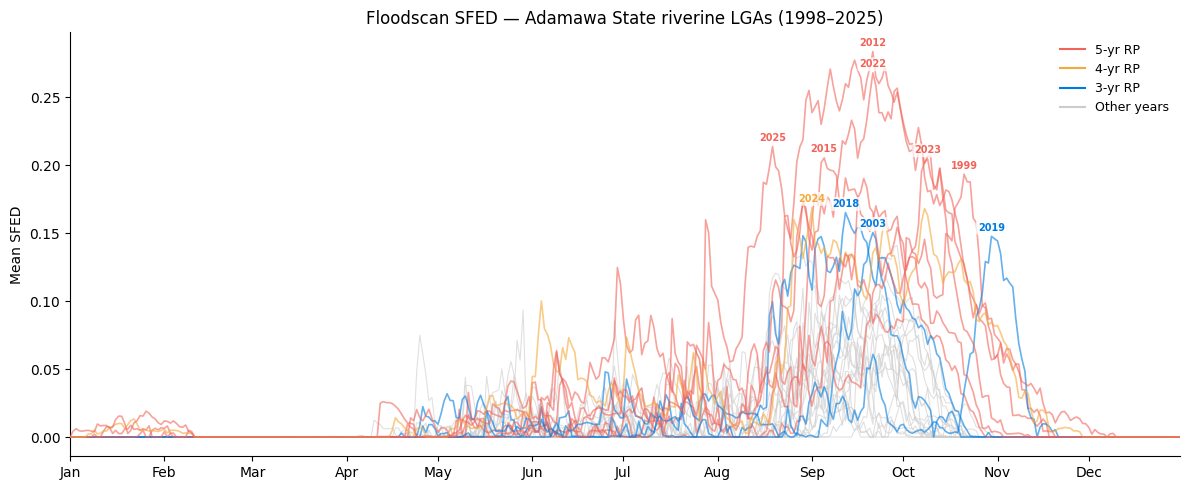

3-yr RP threshold: 0.1476
4-yr RP threshold: 0.1661
5-yr RP threshold: 0.1836


In [10]:
df_fs = stratus.load_parquet_from_blob(cfg["floodscan_blob"])

df_daily = df_fs.groupby("date")["SFED"].mean().reset_index()
df_daily["year"] = df_daily["date"].dt.year
df_daily["month"] = df_daily["date"].dt.month
df_daily["doy_date"] = df_daily["date"].apply(lambda d: d.replace(year=2000))

WET_SEASON_MONTHS = [7, 8, 9, 10, 11]
df_wet = df_daily[df_daily["month"].isin(WET_SEASON_MONTHS)]
annual_max = df_wet.groupby("year")["SFED"].max()

thresh_3yr = annual_max.quantile(1 - 1/3)
thresh_4yr = annual_max.quantile(1 - 1/4)
thresh_5yr = annual_max.quantile(1 - 1/5)

RP_COLORS = {
    "5-yr RP": ("#F2645A", thresh_5yr),
    "4-yr RP": ("#F4A93B", thresh_4yr),
    "3-yr RP": ("#007CE0", thresh_3yr),
}

def year_color(peak):
    if peak >= thresh_5yr: return "#F2645A"
    elif peak >= thresh_4yr: return "#F4A93B"
    elif peak >= thresh_3yr: return "#007CE0"
    return "#CCCCCC"

fig, ax = plt.subplots(figsize=(12, 5))

for zorder, is_colored in [(2, False), (3, True)]:
    for year, group in df_daily.groupby("year"):
        peak = annual_max.get(year, 0)
        color = year_color(peak)
        if (color == "#CCCCCC") == is_colored:
            continue
        group = group.sort_values("doy_date")
        ax.plot(
            group["doy_date"], group["SFED"],
            color=color,
            linewidth=0.8 if color == "#CCCCCC" else 1.2,
            alpha=0.6, zorder=zorder,
        )
        if color != "#CCCCCC":
            peak_row = group.loc[group["SFED"].idxmax()]
            ax.annotate(
                str(year),
                xy=(peak_row["doy_date"], peak_row["SFED"]),
                xytext=(0, 4), textcoords="offset points",
                fontsize=7, ha="center", color=color, fontweight="bold", zorder=5,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75),
            )

legend_handles = [
    plt.Line2D([0], [0], color=color, linewidth=1.5, label=label)
    for label, (color, _) in RP_COLORS.items()
] + [plt.Line2D([0], [0], color="#CCCCCC", linewidth=1.5, label="Other years")]
ax.legend(handles=legend_handles, frameon=False, fontsize=9)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.set_xlim(pd.Timestamp("2000-01-01"), pd.Timestamp("2000-12-31"))
ax.set_xlabel("")
ax.set_ylabel("Mean SFED")
ax.set_title(f"Floodscan SFED — {STATE} State riverine LGAs (1998–2025)", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{STATE.lower()}_sfed_timeseries.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"3-yr RP threshold: {thresh_3yr:.4f}")
print(f"4-yr RP threshold: {thresh_4yr:.4f}")
print(f"5-yr RP threshold: {thresh_5yr:.4f}")